<div style="background:linear-gradient(135deg,#14532d 0%,#15803d 55%,#22c55e 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d6f5e0;font-weight:700;text-transform:uppercase">Chapter 28 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Ames Housing Prices 🏠</div>
  <div style="font-size:15px;color:#e4f7ea;max-width:720px;line-height:1.6">A file of 610 home sales, famous for its missing values. We audit, describe, visualize, then make a deliberate decision for every gap, every date, every outlier, on the way to an analysis-ready table.</div>
  <div style="margin-top:16px;font-size:13px;color:#d2f3dd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; load
Loads from the book's `data/` folder (local) with a GitHub raw-URL fallback (Colab).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CYAN="#0891b2"; AMBER="#d97706"; PURPLE="#7c3aed"; GREEN="#059669"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
pd.set_option("display.max_columns", 30)

BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/ames_housing.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"ames_housing.csv")
raw_rows = len(df)
print("loaded:", df.shape)

loaded: (610, 16)


<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">BEAT 1 · FIRST CONTACT</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">The missingness is the story</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">For Ames, the audit is dominated by missing values, and they are not all missing for the same reason. That distinction drives every decision later.</div>
</div>

In [2]:
print("shape:", df.shape, "| duplicate rows:", int(df.duplicated().sum()))
miss = df.isna().sum()
print("\nmissing (count, %):")
for c in miss[miss>0].sort_values(ascending=False).index:
    print(f"   {c:16s} {miss[c]:4d}   {miss[c]/len(df)*100:5.1f}%")
print("\nsale_date is stored as text, in mixed formats:")
print("  ", df["sale_date"].head(4).to_list())
df.head(3)

shape: (610, 16) | duplicate rows: 10

missing (count, %):
   pool_qc           604    99.0%
   fireplace_qual    290    47.5%
   lot_frontage       98    16.1%
   garage_yr_built    29     4.8%
   sale_price          3     0.5%

sale_date is stored as text, in mixed formats:
   ['09/07/1955', '1940-03-19', '19-Dec-1950', '1945-02-25']


,house_id,neighborhood,lot_area,lot_frontage,year_built,gr_liv_area,bedrooms,full_bath,central_air,fireplace_qual,garage_yr_built,pool_qc,kitchen_qual,exterior_color,sale_date,sale_price
0,1220,Somerset,6339,58.0,1955,885,1,1,Y,NaN,1953.0,NaN,Po,brick,09/07/1955,146251.0
1,1169,OldTown,9227,62.0,1940,1516,4,2,Yes,TA,1945.0,NaN,TA,blue,1940-03-19,99200.0
2,1049,OldTown,12262,36.0,1950,1784,4,2,Y,Gd,1955.0,NaN,Po,beige,19-Dec-1950,135344.0


**The audit:** 10 duplicate rows; `sale_date` sitting in an `object` column in three different formats; and five columns with missing values that span from a trickle (0.5%) to almost everything (99%). The percentages are the clue: a column missing 99% of its values is a different problem from one missing 16%, and we will treat them differently.

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#0891b2;letter-spacing:1px">BEAT 2 · DESCRIBE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Summarize the target</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6"><code>sale_price</code> is what we ultimately want to understand, so we describe it carefully. The headline is a strong <b>right skew</b>, a few expensive homes pull the mean above the median.</div>
</div>

In [3]:
sp = df["sale_price"].dropna()
print(f"mean   ${sp.mean():,.0f}")
print(f"median ${sp.median():,.0f}   (well below the mean -> right skew)")
print(f"SD     ${sp.std():,.0f}    IQR ${sp.quantile(.75)-sp.quantile(.25):,.0f}")
print(f"min ${sp.min():,.0f}   max ${sp.max():,.0f}")
print(f"skewness {sp.skew():+.2f}   (clearly right-skewed)")

mean   $184,147
median $172,879   (well below the mean -> right skew)
SD     $64,748    IQR $78,074
min $68,872   max $518,293
skewness +1.18   (clearly right-skewed)


<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#d97706;letter-spacing:1px">BEAT 3 · VISUALIZE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">See the skew and the outliers</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Two pictures: the price distribution (right-skewed) and a scatter of living area against price. The scatter exposes the famous Ames anomaly, a few enormous houses that sold cheaply.</div>
</div>

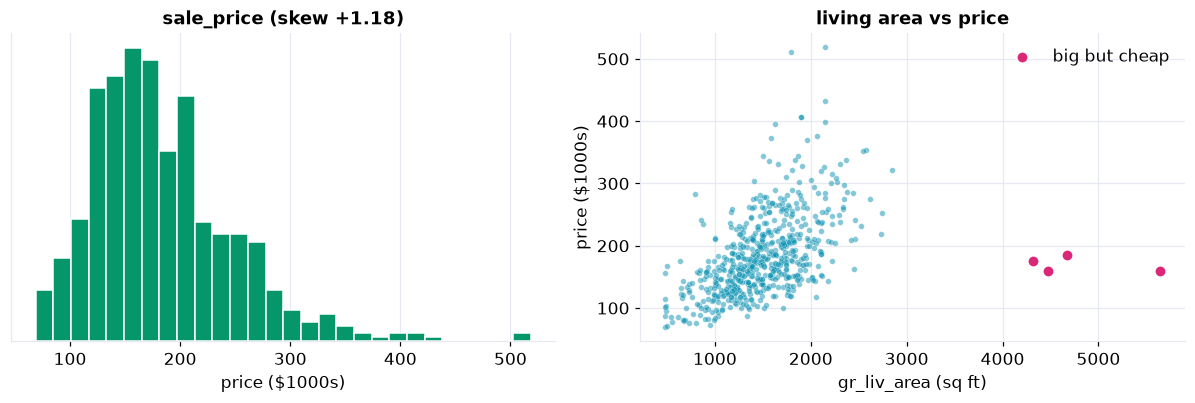

Four houses over 4000 sq ft sold for under $185k: almost certainly partial/family sales.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].hist(sp/1000, bins=28, color=GREEN, edgecolor="white")
ax[0].set_title(f"sale_price (skew {sp.skew():+.2f})"); ax[0].set_xlabel("price ($1000s)"); ax[0].set_yticks([])
sub = df.dropna(subset=["sale_price"])
big = sub["gr_liv_area"] > 4000
ax[1].scatter(sub.loc[~big,"gr_liv_area"], sub.loc[~big,"sale_price"]/1000, s=14, color=CYAN, alpha=0.5, edgecolor="white", linewidth=0.3)
ax[1].scatter(sub.loc[big,"gr_liv_area"], sub.loc[big,"sale_price"]/1000, s=55, color=PINK, edgecolor="white", zorder=5, label="big but cheap")
ax[1].set_xlabel("gr_liv_area (sq ft)"); ax[1].set_ylabel("price ($1000s)"); ax[1].set_title("living area vs price"); ax[1].legend()
plt.tight_layout(); plt.show()
print("Four houses over 4000 sq ft sold for under $185k: almost certainly partial/family sales.")

**What the visuals say:** price is strongly right-skewed (a candidate for a transform later), and most homes follow a clear "bigger sells for more" trend, *except* four giant houses that sold cheap. Those four break the pattern and would distort any line we fit, so we flag them now and deal with them in the preparation step.

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">BEAT 4 · CLEAN</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Duplicates, categories, dates</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Three quick fixes before the missing-value work: drop duplicates (Ch 19), standardize an inconsistent category (Ch 19), and parse the mixed-format dates into real datetimes (Ch 23).</div>
</div>

In [5]:
clean = df.drop_duplicates().copy()
print(f"deduplicate: {raw_rows} -> {len(clean)}  ({raw_rows-len(clean)} exact duplicates)")

# central_air was typed inconsistently
print("central_air before:", clean["central_air"].value_counts().to_dict())
clean["central_air"] = clean["central_air"].replace({"Yes":"Y","No":"N"})
print("central_air after: ", clean["central_air"].value_counts().to_dict())

# two more messy categoricals: kitchen_qual (ORDINAL) and exterior_color (NOMINAL)
clean["kitchen_qual"]   = clean["kitchen_qual"].str.strip().str.upper()
clean["exterior_color"] = clean["exterior_color"].str.strip().str.lower().replace({"grey":"gray"})
print("kitchen_qual:", sorted(clean["kitchen_qual"].unique()), "| exterior_color:", sorted(clean["exterior_color"].unique()))

# parse the three date formats in one shot
clean["sale_date"] = pd.to_datetime(clean["sale_date"], format="mixed")
clean["sale_year"] = clean["sale_date"].dt.year
print("\ndates parsed; unparseable:", int(clean["sale_date"].isna().sum()),
      "| year range:", clean["sale_year"].min(), "-", clean["sale_year"].max())

deduplicate: 610 -> 600  (10 exact duplicates)
central_air before: {'Y': 541, 'N': 51, 'Yes': 8}
central_air after:  {'Y': 549, 'N': 51}
kitchen_qual: ['EX', 'FA', 'GD', 'PO', 'TA'] | exterior_color: ['beige', 'blue', 'brick', 'gray', 'white']

dates parsed; unparseable: 0 | year range: 1900 - 2009


**Why each step:** the 10 exact duplicates would double-count those sales. `central_air` held both `"Y"` and `"Yes"` for the same thing, so a group-by would split one category in two until we standardize it. And a date trapped in text (`"09/07/1955"`, `"19-Dec-1950"`) is useless until parsed; `format="mixed"` reads all three layouts and gives us a real `sale_year` to work with (Chapter 23).

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#7c3aed;letter-spacing:1px">BEAT 5 · MISSING VALUES</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">One column, one decision</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">The signature Ames lesson. Five columns are missing values for <b>different reasons</b>, so each gets a different treatment. The deciding question is always <i>why</i> is it missing.</div>
</div>

In [6]:
# 1) pool_qc: missing for 99% of homes because they have NO pool -> drop the column
pool_missing = clean["pool_qc"].isna().mean()*100
clean = clean.drop(columns=["pool_qc"])
# 2) fireplace_qual: missing = "no fireplace", an informative blank -> recode to a real category
fp_missing = clean["fireplace_qual"].isna().sum()
clean["fireplace_qual"] = clean["fireplace_qual"].fillna("None")
# 3) lot_frontage: a genuine measurement gap (16%) -> median-impute
fr_med = clean["lot_frontage"].median()
clean["lot_frontage"] = clean["lot_frontage"].fillna(fr_med)
# 4) garage_yr_built: missing = no garage -> turn into a has_garage flag, then drop the year
clean["has_garage"] = clean["garage_yr_built"].notna().astype(int)
clean = clean.drop(columns=["garage_yr_built"])
# 5) sale_price: the TARGET -> never invent it; drop those rows
n_price = int(clean["sale_price"].isna().sum())
clean = clean.dropna(subset=["sale_price"])

print(f"pool_qc        : {pool_missing:.0f}% missing -> DROPPED the column")
print(f"fireplace_qual : {fp_missing} blanks -> recoded to \"None\" (no fireplace)")
print(f"lot_frontage   : median-imputed with {fr_med:.0f}")
print(f"garage_yr_built: turned into has_garage flag, year dropped")
print(f"sale_price     : dropped {n_price} rows missing the target")
print("\nremaining missing values:", int(clean.isna().sum().sum()))
print("rows now:", len(clean))

pool_qc        : 99% missing -> DROPPED the column
fireplace_qual : 285 blanks -> recoded to "None" (no fireplace)
lot_frontage   : median-imputed with 70
garage_yr_built: turned into has_garage flag, year dropped
sale_price     : dropped 3 rows missing the target

remaining missing values: 0
rows now: 597


**Five gaps, five answers:** `pool_qc` is 99% empty *because almost no home has a pool*, imputing a fake pool quality is nonsense, so the column goes. `fireplace_qual` blanks also mean "none", but here that is worth keeping as its own category, so we recode rather than drop. `lot_frontage` is an ordinary measurement gap, so we median-impute. `garage_yr_built` missing means "no garage", which is information, so we capture it as a flag. And `sale_price` is the target, so missing rows are dropped, never guessed. The percentage told us where to look; the *reason* told us what to do (Chapter 20).

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#db2777;letter-spacing:1px">BEAT 6 · OUTLIERS &amp; TRANSFORM</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Remove the anomalies, tame the skew</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Now the two numeric fixes. Remove the four impossible big-but-cheap houses (Ch 21), then log-transform the skewed price (Ch 22) so it is well-behaved.</div>
</div>

removed big-but-cheap outliers; rows now 593
gr_liv_area vs price correlation: 0.47 -> 0.58 (cleaner signal)


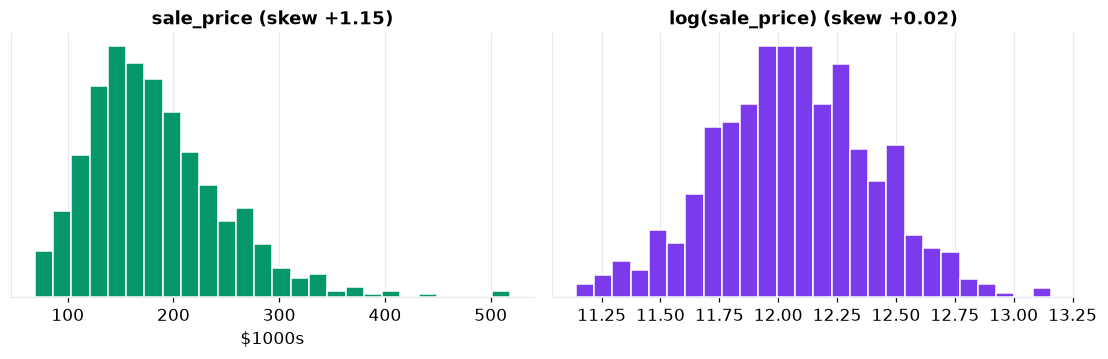

log transform pulled skew from +1.15 to +0.02: now near-symmetric.


In [7]:
# remove the 4 partial-sale outliers; watch the correlation strengthen
r_before = clean["gr_liv_area"].corr(clean["sale_price"])
clean = clean[clean["gr_liv_area"] <= 4000].copy()
r_after = clean["gr_liv_area"].corr(clean["sale_price"])
print(f"removed big-but-cheap outliers; rows now {len(clean)}")
print(f"gr_liv_area vs price correlation: {r_before:.2f} -> {r_after:.2f} (cleaner signal)")

# log-transform the right-skewed price
before = clean["sale_price"].skew()
clean["log_price"] = np.log(clean["sale_price"])
after = clean["log_price"].skew()
fig, ax = plt.subplots(1,2,figsize=(10,3.4))
ax[0].hist(clean["sale_price"]/1000, bins=26, color=GREEN, edgecolor="white")
ax[0].set_title(f"sale_price (skew {before:+.2f})"); ax[0].set_xlabel("$1000s"); ax[0].set_yticks([])
ax[1].hist(clean["log_price"], bins=26, color=PURPLE, edgecolor="white")
ax[1].set_title(f"log(sale_price) (skew {after:+.2f})"); ax[1].set_yticks([])
plt.tight_layout(); plt.show()
print(f"log transform pulled skew from {before:+.2f} to {after:+.2f}: now near-symmetric.")

**Two different tools:** removing the four anomalies is *outlier treatment*, and it immediately strengthens the living-area-to-price relationship from about 0.47 to 0.58 because those four points were fighting the trend (Chapter 21). The log transform is *reshaping*: it compresses the long tail of expensive homes so the distribution is roughly symmetric (skew near 0), which is what regression and many summaries prefer (Chapter 22).

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#15803d;letter-spacing:1px">BEAT 7 · EXPLORE THE CLEAN DATA</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Now the patterns are trustworthy</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">With the data clean, the measurements and grouped charts finally mean something. Measurements first, then the chart that matters most for housing: price by neighborhood.</div>
</div>

In [8]:
def measure(x):
    return pd.Series({
        "mean": x.mean(), "median": x.median(), "mode": x.round(-3).mode().iloc[0],
        "SD": x.std(), "IQR": x.quantile(.75)-x.quantile(.25),
        "CV %": x.std()/x.mean()*100,
        "Q1": x.quantile(.25), "Q3": x.quantile(.75),
        "skew": x.skew(), "kurtosis": x.kurtosis()})
M = pd.DataFrame({"sale_price": measure(clean["sale_price"])}).round(2)
print(M.to_string())

          sale_price
mean       184121.66
median     172941.00
mode       161000.00
SD          64590.82
IQR         78845.00
CV %           35.08
Q1         138376.00
Q3         217221.00
skew            1.15
kurtosis        2.50


**Reading it:** even after dropping the four anomalies, `sale_price` keeps a mild right skew (mean &gt; median, skew &gt; 0, Ch 11) and a coefficient of variation around 35% (Ch 9), homes vary a lot in price. The quartiles say the middle half of homes sold between roughly \$139k and \$217k (Ch 10). This is the kind of numeric profile you would quote to summarize a market.

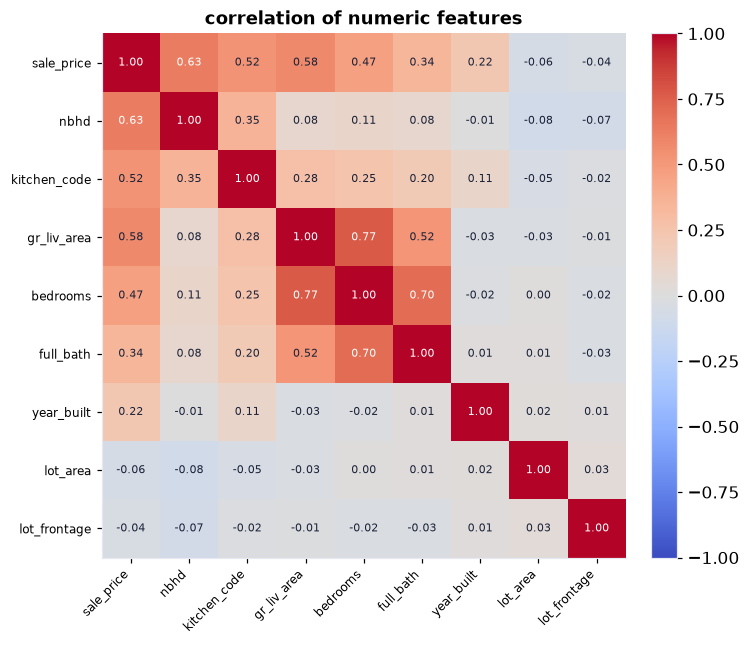

price corr: {'nbhd': 0.63, 'kitchen_code': 0.52, 'gr_liv_area': 0.58, 'bedrooms': 0.47, 'full_bath': 0.34, 'year_built': 0.22, 'lot_area': -0.06, 'lot_frontage': -0.04}


In [9]:
# encode the categoricals so they enter the heatmap (Ch 24)
clean["nbhd"] = clean.groupby("neighborhood")["sale_price"].transform("median")   # target/mean
clean["kitchen_code"] = clean["kitchen_qual"].map({"PO":1,"FA":2,"TA":3,"GD":4,"EX":5})  # ORDINAL 1..5

# Ch 16: a correlation heatmap of the numeric features + encoded neighborhood & kitchen
feat = ["sale_price","nbhd","kitchen_code","gr_liv_area","bedrooms","full_bath","year_built","lot_area","lot_frontage"]
corr = clean[feat].corr()
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat, fontsize=8)
for i in range(len(feat)):
    for j in range(len(feat)):
        v = corr.iloc[i,j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v)>0.6 else "#1a2138")
ax.set_title("correlation of numeric features"); ax.grid(False)
plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()
print("price corr:", corr["sale_price"].drop("sale_price").round(2).to_dict())

**Reading the heatmap:** both encoded categoricals now sit in the matrix. **Neighborhood (0.63) is the strongest correlate of `sale_price`**, then living area (0.58), and the ordinal **kitchen quality (0.52)** is third, just ahead of bedrooms (0.47). The two encodings did exactly what each type should: the nominal neighborhood became a single mean-encoded number, the ordinal kitchen_qual became 1 to 5 with its order intact, and both turned out to be genuinely useful. The size features still form a **warm collinear block among themselves** (0.5 to 0.77), so for a linear model you would select or combine them (Chapter 24). One caution: the mean-encoded neighborhood is built from price, so its correlation is mildly optimistic; in a real model you would cross-fit it to avoid leakage (Chapter 24).

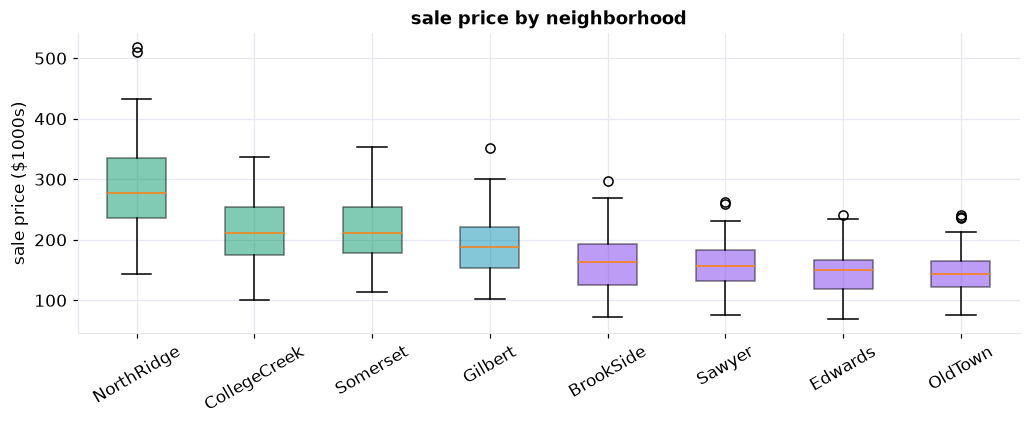

NorthRidge median ~$276k vs OldTown ~$146k: location is the biggest price lever.


In [10]:
# Ch 16: price varies hugely by neighborhood, the single most useful grouping
order = clean.groupby("neighborhood")["sale_price"].median().sort_values(ascending=False).index
data  = [clean.loc[clean["neighborhood"]==n, "sale_price"].values/1000 for n in order]
fig, ax = plt.subplots(figsize=(9.5,4))
bp = ax.boxplot(data, patch_artist=True, tick_labels=list(order))
for patch, n in zip(bp["boxes"], order):
    med = clean.loc[clean["neighborhood"]==n,"sale_price"].median()/1000
    patch.set_facecolor(GREEN if med>200 else (CYAN if med>165 else PURPLE)); patch.set_alpha(0.5)
ax.set_ylabel("sale price ($1000s)"); ax.set_title("sale price by neighborhood")
ax.tick_params(axis="x", rotation=30); plt.tight_layout(); plt.show()
print("NorthRidge median ~$276k vs OldTown ~$146k: location is the biggest price lever.")

In [11]:
# correlations with price (clean), and one-hot encode neighborhood
num = ["lot_area","lot_frontage","year_built","gr_liv_area","bedrooms","full_bath","sale_price"]
print("correlation with sale_price (clean):")
print(clean[num].corr()["sale_price"].drop("sale_price").sort_values(ascending=False).round(2).to_string())

hood_oh  = pd.get_dummies(clean["neighborhood"], prefix="nb")     # nominal -> one-hot
color_oh = pd.get_dummies(clean["exterior_color"], prefix="ext")  # nominal -> one-hot
ready = pd.concat([clean[["gr_liv_area","lot_area","year_built","bedrooms","full_bath",
                          "has_garage","kitchen_code","log_price"]].reset_index(drop=True),
                   hood_oh.reset_index(drop=True), color_oh.reset_index(drop=True)], axis=1)
print("\nANALYSIS-READY:", ready.shape)
print(f"journey: {raw_rows} raw rows -> {len(ready)} clean rows, {ready.shape[1]} model-ready columns")

correlation with sale_price (clean):
gr_liv_area     0.58
bedrooms        0.47
full_bath       0.34
year_built      0.22
lot_frontage   -0.04
lot_area       -0.06

ANALYSIS-READY: (593, 21)
journey: 610 raw rows -> 593 clean rows, 21 model-ready columns


**The clean story:** living area is the strongest single numeric driver of price (now r ≈ 0.58 after the outliers were removed), but the box plots show that *neighborhood* matters even more, NorthRidge homes sell for nearly double those in OldTown (Ch 15/16). That is a finding a buyer or seller would actually pay for, and it only emerged once the data was trustworthy.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap: what we did and why</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Deduplicated</b> 10 exact-copy sales (Ch 19) and <b>standardized</b> central_air (Yes → Y).</li>
<li><b>Parsed</b> three date formats into real datetimes and a usable sale_year (Ch 23).</li>
<li><b>Missing values, five different answers</b> (Ch 20): dropped pool_qc (99% empty), recoded fireplace_qual to "None", median-imputed lot_frontage, flagged has_garage, dropped rows missing the price target.</li>
<li><b>Removed</b> 4 big-but-cheap outliers, lifting living-area correlation 0.47 → 0.58 (Ch 21).</li>
<li><b>Log-transformed</b> the skewed price (+1.16 → +0.02) and <b>one-hot encoded</b> neighborhood (Ch 22 &amp; 24).</li>
</ul>
<div style="color:#4a5578;line-height:1.7;margin-top:6px">The finding: <b>location beats size</b>, neighborhood medians range from ~$146k to ~$276k, a bigger lever than any single house feature.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>